In [1]:
from conf.default import get_cfg_defaults
from Noise2Model.data import preprocessing, get_png_img_paths, parse_file_name
from Noise2Model.trainer import get_trainer_class

In [2]:
!gpustat

Merlin                      Tue Feb 10 11:47:08 2026  576.02
[0] NVIDIA GeForce RTX 4090 | 47°C,  15 % |  1889 / 24564 MB |
[1] NVIDIA GeForce RTX 4090 | 25°C,   0 % |     0 / 24564 MB |


In [3]:
from torch.cuda import is_available
print(is_available())

True


In [4]:
img_path = '../../_data/04-mito-20x-noise1/'

In [5]:
img_paths = get_png_img_paths(img_path)[:1]

for img_idx, imgpath in enumerate((img_paths)):
    print(f'Processing image {img_idx+1}/{len(img_paths)}: {imgpath}')

Processing image 1/1: {'GT': '../../_data/04-mito-20x-noise1/GT/mito-20x-noise1-0020.png', 'NOISY': '../../_data/04-mito-20x-noise1/raw/mito-20x-noise1-0020.png'}


In [6]:
parse_file_name(imgpath)

{'scene-instance-number': 20,
 'scene-number': 1,
 'optical-setup': 3,
 'camera': 0,
 'exposure-time': 60,
 'wavelength': 600,
 'sample-code': 0}

In [7]:
import cv2
img_gt = cv2.imread(imgpath['GT'], cv2.IMREAD_ANYDEPTH)

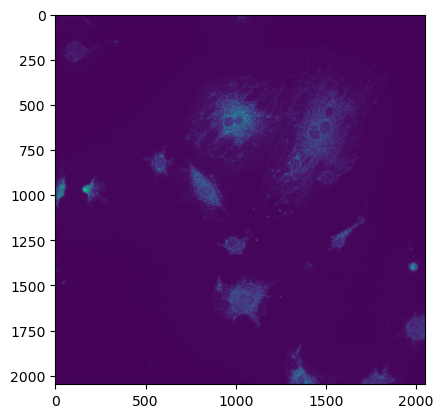

In [8]:
import matplotlib.pyplot as plt 
plt.imshow(img_gt)

In [9]:
preprocessing(img_path,
              patch_size= 96,
              step= 80,
              output_base_path='../../_data/HDF5_04-mito-20x-noise1_s96_o08', 
              get_img_paths_func=get_png_img_paths,
              parse_config=parse_file_name,
              train_noisegen_idx=[i for i in range(1,10)],
              test_idx=[99],
              overwrite=True,)

100%|██████████| 100/100 [00:08<00:00, 12.12it/s]


../../_data/HDF5_04-mito-20x-noise1_s96_o08/noise_gen/test/0088_GT.hdf5
(1, 96, 96)


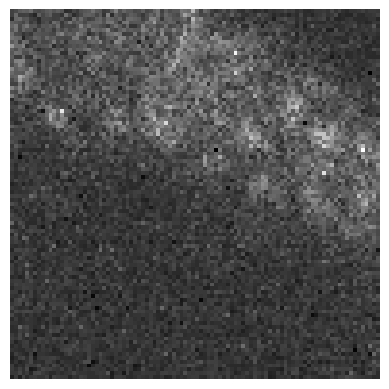

(1, 96, 96)


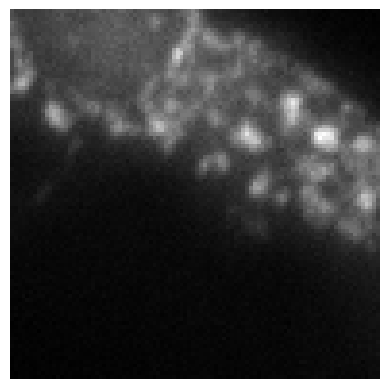

In [10]:
from Noise2Model.data import load_and_display_hdf5_image
output_base_path = '../../_data/HDF5_04-mito-20x-noise1_s96_o08'
file_path = output_base_path + '/noise_gen/test/0088_GT.hdf5'
print(file_path)
for i in range(70,71):
    n = load_and_display_hdf5_image(file_path, dataset_name='noisy', patch_num=i)
    c = load_and_display_hdf5_image(file_path, dataset_name='clean', patch_num=i)

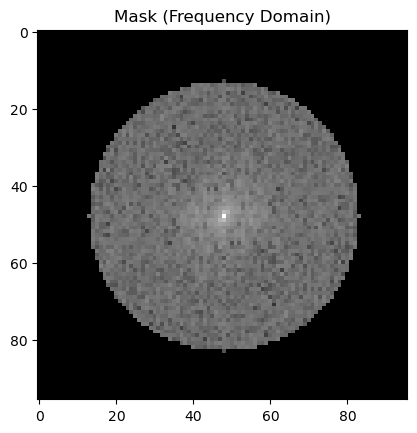

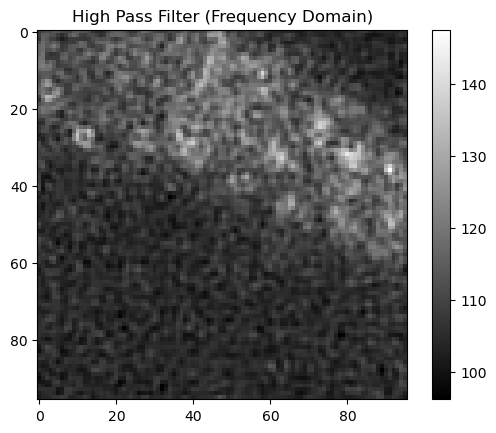

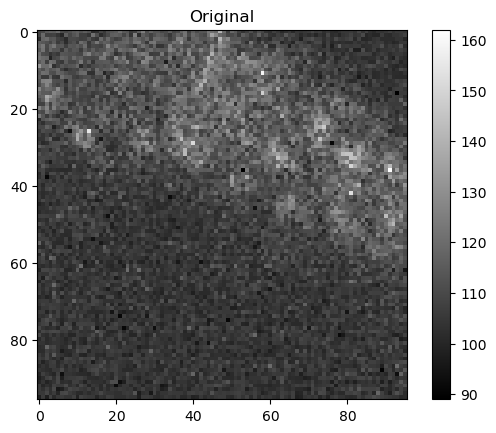

In [112]:
import numpy as np

f = np.fft.fft2(n[0])
fshift = np.fft.fftshift(f)

# Create a mask to block low frequencies (center region)
import numpy as np

def create_circular_mask(h, w, center=None, radius=None):
    if center is None:
        center = (w // 2, h // 2)
    if radius is None:
        radius = min(center[0], center[1], w - center[0], h - center[1])
    
    cy, cx = center  # Unpack y, x (row, col)
    Y, X = np.ogrid[:h, :w]
    dist_from_center = np.sqrt((X - cx)**2 + (Y - cy)**2)
    mask = dist_from_center <= radius
    return mask


rows, cols = n[0].shape
mask = create_circular_mask(rows, cols, radius=35)   

fshift = fshift * mask
f_ishift = np.fft.ifftshift(fshift)
img_back = np.fft.ifft2(f_ishift)
img_back = np.abs(img_back)

plt.imshow(np.log1p(abs(fshift)), cmap='gray')
plt.title('Mask (Frequency Domain)')
plt.show()

plt.imshow(img_back, cmap='gray')
plt.title('High Pass Filter (Frequency Domain)')
plt.colorbar();
plt.show()   


plt.imshow(n[0], cmap='gray')
plt.title('Original')
plt.colorbar();
plt.show()  


In [113]:
def normalize_image(img, method='minmax'):
    """
    Normalize image to [0, 1] range.
    
    Args:
        img: numpy array (uint16 or other dtype)
        method: 'minmax' for min-max normalization, 'standard' for standardization
    
    Returns:
        Normalized image as float32
    """
    img = img.astype('float32')
    
    if method == 'minmax':
        img_min = img.min()
        img_max = img.max()
        return (img - img_min) / (img_max - img_min)
    elif method == 'standard':
        return (img - img.mean()) / img.std()
    else:
        raise ValueError(f"Unknown method: {method}")

# Normalize using default minmax method
c_normalized = normalize_image(c)
n_normalized = normalize_image(n)

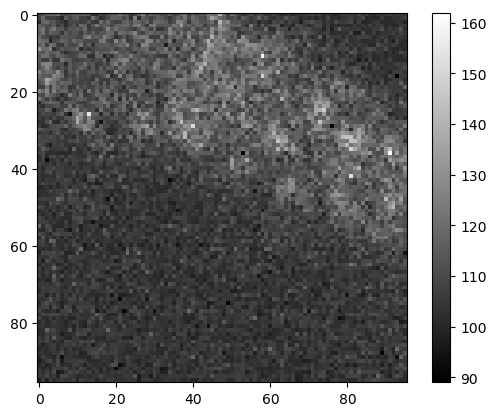

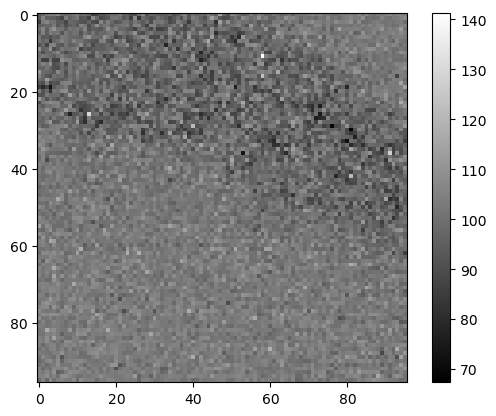

In [114]:
import matplotlib.pyplot as plt

img_min = img_back.min()
img_max = img_back.max()

plt.imshow((n[0]), 'gray')
plt.colorbar();
plt.show()
plt.imshow(n[0] - normalize_image(c[0])*(img_max - img_min), 'gray')
plt.colorbar();
plt.show()

In [115]:
# from Noise2Model.utils import save_img
# dir_name = '/home/biagio/Noise2Model/nbs/demos'
# file_name = 'test.png'
# save_img(dir_name,file_name, img)

In [116]:
# device = '1'

# config = get_cfg_defaults()
# config.merge_from_file('../../conf/NMFlowGAN_NoiseModeler5.yaml')


In [117]:
# # intialize trainer
# trainer = get_trainer_class(config.BASE.trainer)(config)
# trainer.set_device(device)
# trainer.train()
